In [264]:
from alerce.core import Alerce
import pandas as pd
from astropy.table import vstack, Table
import matplotlib.pyplot as plt
import pyvo as vo
import requests
import sqlalchemy as sa
import sys
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u
import re
import george
import scipy.optimize as op
import emcee
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn import metrics
from sklearn.neighbors import KNeighborsClassifier
from sklearn import svm
from sklearn.preprocessing import RobustScaler
from sklearn.inspection import permutation_importance

In [245]:
#load in data
sn1a1 = Table.read("../Data/SNIa_fits1.ecsv")
sn1a2 = Table.read("../Data/SNIa_fits2.ecsv")
snII = Table.read("../Data/SNII_fits.ecsv")
snIb = Table.read("../Data/SNIb_fits.ecsv")
snIc = Table.read("../Data/SNIc_fits.ecsv")

In [246]:
#combine data
rises = []
falls = []
peaks = []
label = []
SNe = [sn1a1, sn1a2, snII, snIb, snIc]
encoder = np.array(["SNIa", "SNII", "SNIb", "SNIc"])

for sn in SNe:
    for stype, peak, rise, fall in zip(sn["type"], sn["peak"], sn["rise"], sn["fall"]):
        l = np.where(encoder == stype)[0]
        rises.append(rise)
        falls.append(fall)
        peaks.append(peak)
        label.append(l)

rises = np.array(rises)
falls = np.array(falls)
peaks = np.array(peaks)

In [247]:
#build feature space
features = Table([rises, peaks, falls], names=["Rise", "Peak", "Fall"]).to_pandas()

In [248]:
arg = features["Peak"].max()
arg

np.float64(2.3190295046575453e-18)

In [249]:
#normalize data
transformer = RobustScaler().fit(features)
features_n = transformer.transform(features)

In [250]:
#resample
resampler = SMOTE(sampling_strategy="auto", k_neighbors=3)


features_resampled, labels_resampled = resampler.fit_resample(features_n, label)

In [251]:
# #initializing primary components
# pca = PCA(n_components=3)

# #training pca
# pca.fit(features_resampled)
# #print(len(wine.data))

# #reducing data
# features_pca = pca.transform(features_resampled)
# #print(wine_pca)

# #making data frame
# features_pca_df = pd.DataFrame(features_pca)

In [252]:
#initialize ml
clf = RandomForestClassifier(max_depth=None, random_state=0)

#use ml with cross validation
predict_clf = cross_val_predict(clf, features_resampled, labels_resampled)

features_resampled = pd.DataFrame(features_resampled)

In [253]:
features_resampled.columns = ["Rise", "Peak", "Fall"]

In [254]:
# dropped = features_resampled
# dropped_labels = labels_resampled
# for r in range(0, 280):
#     index = np.argmax(dropped[1])
#     dropped = dropped.drop(index)
#     junk = dropped_labels.pop(index)

In [255]:
mask = features_resampled["Peak"] < 10**-22
masked_f = features_resampled[mask]
masked_l = np.array(labels_resampled)[mask]

array([[<Axes: xlabel='Rise', ylabel='Rise'>,
        <Axes: xlabel='Peak', ylabel='Rise'>,
        <Axes: xlabel='Fall', ylabel='Rise'>],
       [<Axes: xlabel='Rise', ylabel='Peak'>,
        <Axes: xlabel='Peak', ylabel='Peak'>,
        <Axes: xlabel='Fall', ylabel='Peak'>],
       [<Axes: xlabel='Rise', ylabel='Fall'>,
        <Axes: xlabel='Peak', ylabel='Fall'>,
        <Axes: xlabel='Fall', ylabel='Fall'>]], dtype=object)

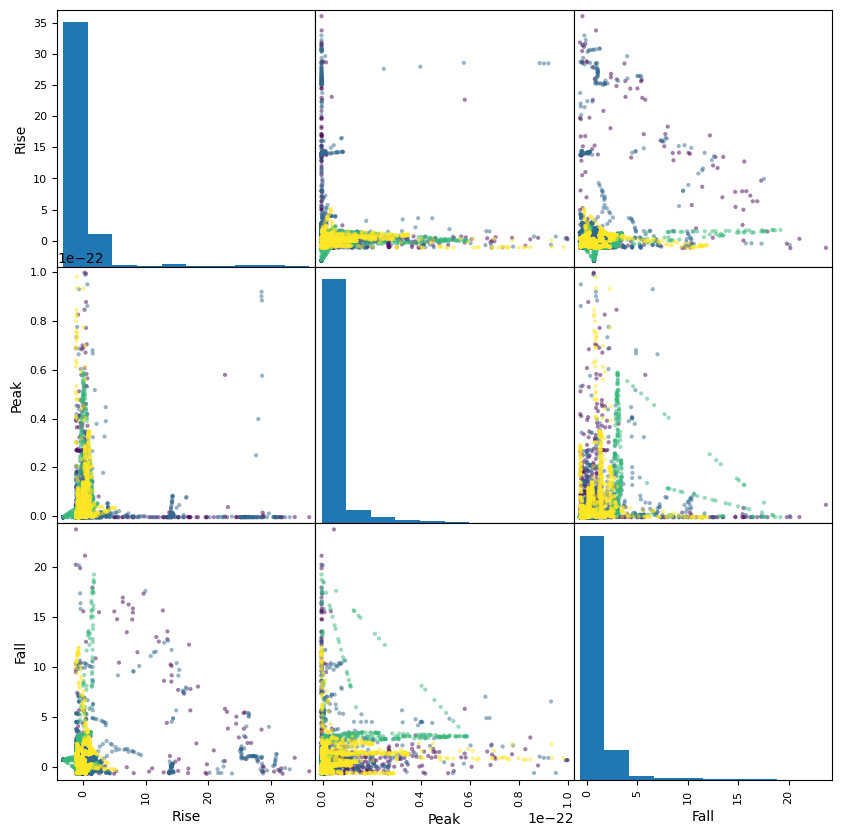

In [256]:
pd.plotting.scatter_matrix(masked_f, figsize=(10,10), c=masked_l, cmap="viridis")

In [257]:
print(f"Accuracy: {np.sum(np.logical_and(predict_clf, labels_resampled))/len(labels_resampled)}")

Accuracy: 0.6722857142857143


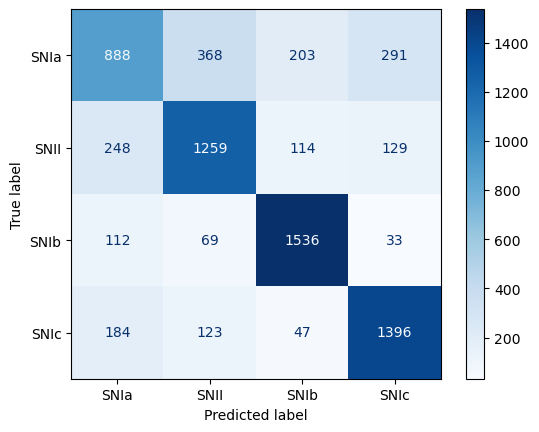

In [261]:
confusion_matrix = metrics.cluster.contingency_matrix(labels_resampled, predict_clf)
class_names = ["SNIa", "SNII", "SNIb", "SNIc"]

disp = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.show()

Text(0.5, 0.98, 'Normalized by Row')

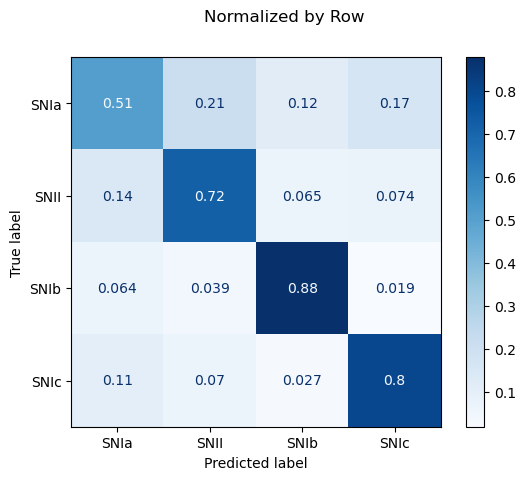

In [262]:
confusion_matrix_row = metrics.confusion_matrix(labels_resampled, predict_clf, normalize="true")
disp2 = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_row, display_labels=class_names)
disp2.plot(cmap=plt.cm.Blues)
plt.suptitle("Normalized by Row")

Text(0.5, 0.98, 'Normalized by Col')

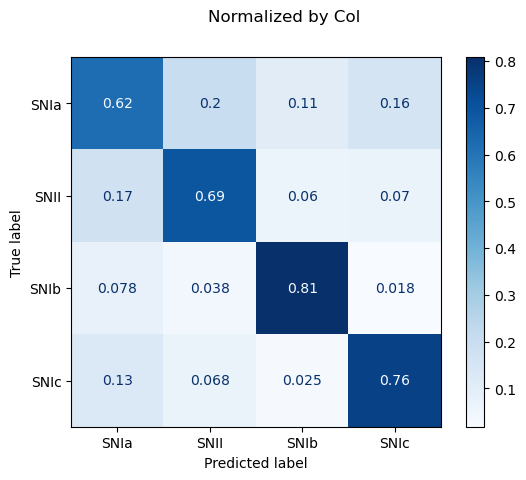

In [263]:
confusion_matrix_row = metrics.confusion_matrix(labels_resampled, predict_clf, normalize="pred")
disp2 = metrics.ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_row, display_labels=class_names)
disp2.plot(cmap=plt.cm.Blues)
plt.suptitle("Normalized by Col")

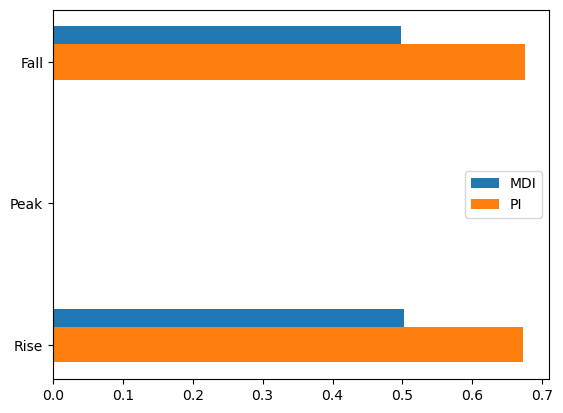

In [269]:
clf.fit(features_resampled, labels_resampled)
feature_names = ["Rise", "Peak", "Fall"]

MDI = clf.feature_importances_
plt.barh(feature_names, MDI, label="MDI", height=0.25, align="edge")

PI = permutation_importance(clf, features_resampled, labels_resampled, n_repeats=10, random_state=0)
plt.barh(feature_names, PI.importances_mean, label="PI", height=0.25)

plt.legend()